In [1]:
# Load the necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# 1. Generate sample customer dataset
np.random.seed(42)
n_customers = 150

data = {
    'customer_id': range(1, n_customers + 1),
    'total_purchases': np.random.poisson(20, n_customers),
    'website_visits': np.random.poisson(50, n_customers),
    'loyalty_points': np.random.normal(700, 150, n_customers).astype(int),
    'last_visit_days_ago': np.random.randint(1, 31, n_customers),
    'campaign_exposed': np.random.choice([0, 1], n_customers, p=[0.7, 0.3])
}
df = pd.DataFrame(data)

In [3]:
# 2. Clean/transform: Remove outliers and scale features
df = df[df['loyalty_points'] > 0]
features = ['total_purchases', 'website_visits', 'loyalty_points', 'last_visit_days_ago']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

In [4]:
# 3. Audience segmentation: KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['segment'] = kmeans.fit_predict(df_scaled)

In [5]:
# 4. Campaign performance: Simple uplift calculation
# Define outcome as at least 1 purchase in last 7 days
df['recent_purchaser'] = df['last_visit_days_ago'] <= 7
control = df[(df['campaign_exposed'] == 0)]
treatment = df[(df['campaign_exposed'] == 1)]

uplift = treatment['recent_purchaser'].mean() - control['recent_purchaser'].mean()

print(f"Campaign Uplift: {uplift:.2%}")

Campaign Uplift: 2.21%


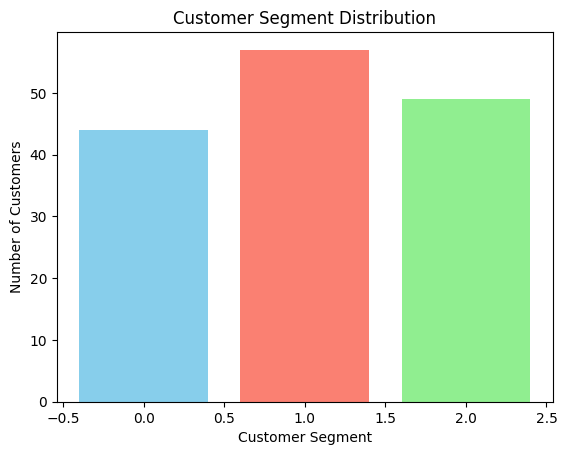

In [6]:
# 5. Visualization: Segment breakdown
segment_counts = df['segment'].value_counts().sort_index()
plt.bar(segment_counts.index, segment_counts.values, color=['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segment Distribution')
plt.show()

In [7]:
# 6. Insights
for seg in sorted(df['segment'].unique()):
    avg_purch = df[df['segment'] == seg]['total_purchases'].mean()
    print(f"Segment {seg}: Avg Purchases = {avg_purch:.1f}")

Segment 0: Avg Purchases = 24.7
Segment 1: Avg Purchases = 18.6
Segment 2: Avg Purchases = 17.9


Explanation

* Steps 1–2: Simulate customer-level data and perform basic cleaning and feature scaling.

* Step 3: Use clustering for audience creation, mimicking segmentation tasks.

* Step 4: Simulate a basic campaign performance measure (recent purchasers uplift).

* Step 5: Create a simple visualization—segment size bar chart.

* Step 6: Output sample business insights per segment.

This code forms a baseline workflow that could be built upon for audience modeling and campaign reporting, translating technical analytics into actionable business stories as outlined in the job description.